### 1. ChEMBL data curation

In [ ]:
from rdkit import Chem
from rdkit.Chem import MolStandardize
import pandas as pd
import numpy as np

In [ ]:
ido = pd.read_csv("ido_CHEMBL4685.csv")
tdo = pd.read_csv("tdo_CHEMBL2140.csv")
ido

,molecule_chembl_id,smiles,standard_type,standard_relation,standard_value,standard_units,pChEMBL_value
0,CHEMBL1542642,NN=C(S)Nc1ccc(Cl)cc1,IC50,'>',50000.0,nM,NaN
1,CHEMBL3286604,NNC(=S)Nc1ccc([N+](=O)[O-])cc1,IC50,'>',50000.0,nM,NaN
2,CHEMBL4847481,Cc1nccc(N2c3ccc(C4(NC(=O)c5ccc(F)cc5)CC4)cc3[C...,IC50,NaN,NaN,NaN,NaN
3,CHEMBL4755484,O=[N+]([O-])c1ccc(N/C(Cc2cccc(Cl)c2)=N\O)c2nonc12,IC50,'=',199.0,nM,6.70
4,CHEMBL4763934,O=C1c2ccccc2C(=O)c2c1nnn2-c1ccc2ccncc2c1,IC50,'=',40.0,nM,7.40
...,...,...,...,...,...,...,...
4610,CHEMBL14145,c1ccc(-c2c[nH]cn2)cc1,IC50,'>',30000.0,nM,NaN
4611,CHEMBL15192,CC1(C)CCC2=C(O1)c1ccccc1C(=O)C2=O,IC50,'=',440.0,nM,6.36
4612,CHEMBL4791168,COP(C)(=O)NCCCNc1nonc1/C(=N/O)Nc1ccc(F)c(Br)c1,IC50,'=',2.6,nM,8.59
4613,CHEMBL3545369,NS(=O)(=O)NCCNc1nonc1/C(=N/O)Nc1ccc(F)c(Br)c1,IC50,'=',77.8,nM,7.11


In [ ]:
ido['standard_relation'].unique()

array(["'>'", nan, "'='", "'<'"], dtype=object)

In [ ]:
tdo['standard_relation'].unique()

array(["'='", "'>'", nan, "'<'"], dtype=object)

In [ ]:
ido.loc[:, 'standard_relation'] = ido['standard_relation'].str.replace("'", "").str.strip()
tdo.loc[:, 'standard_relation'] = tdo['standard_relation'].str.replace("'", "").str.strip()

In [ ]:
ido_cleaned = ido[ido['standard_relation'] == '=']
tdo_cleaned = tdo[tdo['standard_relation'] == '=']

In [ ]:
tdo_cleaned

,molecule_chembl_id,smiles,standard_type,standard_relation,standard_value,standard_units,pChEMBL_value
0,CHEMBL4748868,O=C1c2ccccc2C(=O)c2c1nnn2-c1ccc(F)cc1,IC50,=,49.0,nM,7.31
2,CHEMBL5218772,Cc1ccc(C(=O)CC(=O)c2ccccc2OC(C)C)c(O)c1,IC50,=,10800.0,nM,4.97
3,CHEMBL5176261,O=[N+]([O-])c1ccccc1CNc1cccc2[nH]ncc12,IC50,=,16950.0,nM,4.77
5,CHEMBL5191984,CC(=O)O[C@H]1CCc2c(ccc3c2C(=O)C(=O)c2c(CO)coc2...,IC50,=,1910.0,nM,5.72
6,CHEMBL5220441,Brc1cc(NCC2CCNC2)c2cn[nH]c2c1,IC50,=,10440.0,nM,4.98
...,...,...,...,...,...,...,...
1088,CHEMBL312537,Cc1ccc2c(c1)C(=O)c1nc3ccccc3c(=O)n1-2,IC50,=,215.0,nM,6.67
1090,CHEMBL3545369,NS(=O)(=O)NCCNc1nonc1/C(=N/O)Nc1ccc(F)c(Br)c1,IC50,=,260.0,nM,6.58
1094,CHEMBL355606,Fc1ccc2c(/C=C/c3cccnc3)c[nH]c2c1,IC50,=,492.0,nM,6.31
1095,CHEMBL4092918,O=C1c2ccccc2C2=C3C(O)=NN=C3CCN12,IC50,=,4350.0,nM,5.36


In [ ]:
# Convert Standard Value to float
ido_cleaned["standard_value"] = ido_cleaned["standard_value"].astype(float)
tdo_cleaned["standard_value"] = tdo_cleaned["standard_value"].astype(float)

# Group by SMILES and compute mean IC50
ido_unique = ido_cleaned.groupby("smiles", as_index=False)["standard_value"].mean()
tdo_unique = tdo_cleaned.groupby("smiles", as_index=False)["standard_value"].mean()

/tmp/ipykernel_700/2587283070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ido_cleaned["standard_value"] = ido_cleaned["standard_value"].astype(float)
/tmp/ipykernel_700/2587283070.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdo_cleaned["standard_value"] = tdo_cleaned["standard_value"].astype(float)


In [ ]:
# Compute pIC50 = -log10(IC50 in M)
def compute_pIC50(nm_val):
    return -np.log10(nm_val * 1e-9)

ido_unique["pIC50_IDO1"] = ido_unique["standard_value"].apply(compute_pIC50)
tdo_unique["pIC50_TDO"] = tdo_unique["standard_value"].apply(compute_pIC50)

In [ ]:
print(ido_unique.columns)
print(tdo_unique.columns)

Index(['smiles', 'standard_value', 'pIC50_IDO1'], dtype='object')
Index(['smiles', 'standard_value', 'pIC50_TDO'], dtype='object')


In [ ]:
# Merge on SMILES
merged = pd.merge(ido_unique, tdo_unique, on="smiles", how="inner")

# Keep only relevant columns
merged = merged[["smiles", "pIC50_IDO1", "pIC50_TDO"]]

# Save to CSV
merged.to_csv("dual_target_qsar.csv", index=False)

In [ ]:
merged

,smiles,pIC50_IDO1,pIC50_TDO
0,Brc1cc(NCC2CCCCC2)c2cn[nH]c2c1,5.962574,6.065502
1,Brc1cc(NCC2CCCCC23OCCO3)c2cn[nH]c2c1,4.493901,5.690370
2,Brc1cc(NCC2CCNC2)c2cn[nH]c2c1,3.979225,4.981300
3,Brc1cc(NCC2CNC2)c2cn[nH]c2c1,3.948076,4.348044
4,Brc1cc(NC[C@@H]2CCCCN2)c2cn[nH]c2c1,4.861697,5.217527
...,...,...,...
408,Oc1ccc(F)cc1-c1cncn1Cc1cc2cc(F)ccc2[nH]1,6.946922,4.075721
409,Oc1ccccc1-c1nc2c3ccccc3c3ccccc3c2[nH]1,4.753707,4.911864
410,c1ccc2c(c1)[nH]c1c(-c3c[nH]cn3)nccc12,5.452225,5.939302
411,c1ccc2c(c1)[nH]c1c(-c3cnn[nH]3)nccc12,4.857611,4.709743


In [ ]:
from rdkit import Chem, RDLogger
from rdkit.Chem import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize

# Silence RDKit logs
RDLogger.DisableLog('rdApp.*')

remover = SaltRemover.SaltRemover()
normalizer = rdMolStandardize.Normalizer()
uncharger = rdMolStandardize.Uncharger()
tautomer_enumerator = rdMolStandardize.TautomerEnumerator()

def standardize_smiles(smiles):
    if pd.isnull(smiles):
        return smiles
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = remover.StripMol(mol)
    mol = normalizer.normalize(mol)
    mol = uncharger.uncharge(mol)
    mol = tautomer_enumerator.Canonicalize(mol)
    return Chem.MolToSmiles(mol, canonical=True)

merged['smiles'] = merged['smiles'].apply(standardize_smiles)

### 2. Molecular fingerprints generation

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
from tqdm import tqdm

# ECFP4 generator
def get_ecfp4_array(smiles, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=nBits)
        return list(fp)
    else:
        return None

# Enable tqdm progress
tqdm.pandas()

# Apply on your final dataset with progress bar
merged['ecfp4'] = merged['smiles'].progress_apply(get_ecfp4_array)

# Drop any failed rows
merged = merged[merged['ecfp4'].notnull()].reset_index(drop=True)

# Expand fingerprints to 2048 columns
fp_df = pd.DataFrame(merged['ecfp4'].to_list(), columns=[f'fp_{i}' for i in range(2048)])

# Join and save
merged_ecfp4 = pd.concat([merged.drop(columns=['ecfp4']), fp_df], axis=1)
merged_ecfp4.to_csv("ido1_tdo_ecfp4.csv", index=False)

100%|███████████████████████████████████████████████████████████████████████████████| 413/413 [00:00<00:00, 1675.16it/s]


### 3. Model construction

In [ ]:
import pandas as pd
df_final = pd.read_csv("ido1_tdo_ecfp4.csv")
df_final

,smiles,pIC50_IDO1,pIC50_TDO,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,Brc1cc(NCC2CCCCC2)c2c[nH]nc2c1,5.962574,6.065502,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Brc1cc(NCC2CCCCC23OCCO3)c2c[nH]nc2c1,4.493901,5.690370,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Brc1cc(NCC2CCNC2)c2c[nH]nc2c1,3.979225,4.981300,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Brc1cc(NCC2CNC2)c2c[nH]nc2c1,3.948076,4.348044,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Brc1cc(NC[C@@H]2CCCCN2)c2c[nH]nc2c1,4.861697,5.217527,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,Oc1ccc(F)cc1-c1cncn1Cc1cc2cc(F)ccc2[nH]1,6.946922,4.075721,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
409,Oc1ccccc1-c1nc2c3ccccc3c3ccccc3c2[nH]1,4.753707,4.911864,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
410,c1ccc2c(c1)[nH]c1c(-c3c[nH]cn3)nccc12,5.452225,5.939302,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
411,c1ccc2c(c1)[nH]c1c(-c3c[nH]nn3)nccc12,4.857611,4.709743,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

y = df_final[['pIC50_IDO1', 'pIC50_TDO']]

X = df_final.drop(columns=['pIC50_IDO1', 'pIC50_TDO', 'smiles'], errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

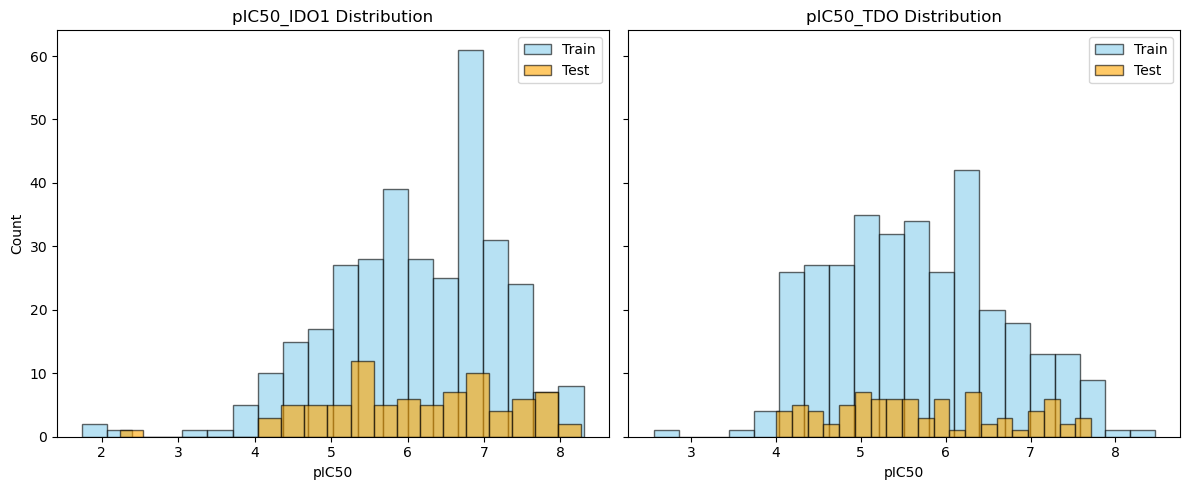

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# IDO1
axes[0].hist(y_train['pIC50_IDO1'], bins=20, alpha=0.6, label="Train", color="skyblue", edgecolor="black")
axes[0].hist(y_test['pIC50_IDO1'], bins=20, alpha=0.6, label="Test", color="orange", edgecolor="black")
axes[0].set_title("pIC50_IDO1 Distribution")
axes[0].set_xlabel("pIC50")
axes[0].set_ylabel("Count")
axes[0].legend()

# TDO
axes[1].hist(y_train['pIC50_TDO'], bins=20, alpha=0.6, label="Train", color="skyblue", edgecolor="black")
axes[1].hist(y_test['pIC50_TDO'], bins=20, alpha=0.6, label="Test", color="orange", edgecolor="black")
axes[1].set_title("pIC50_TDO Distribution")
axes[1].set_xlabel("pIC50")
axes[1].legend()

plt.tight_layout()
plt.savefig("pIC50_distr.png", dpi=300)
plt.show()

In [ ]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import pandas as pd

# 1. Drop low-variance features from training set
var_thresh = VarianceThreshold(threshold=0.1)
X_train_var = var_thresh.fit_transform(X_train)

# Get names of retained features
kept_var_cols = X_train.columns[var_thresh.get_support()]

# 2. Drop highly correlated features (based on training set only)
X_train_var_df = pd.DataFrame(X_train_var, columns=kept_var_cols)

corr_matrix = X_train_var_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

# Final cleaned feature sets
X_train_clean = X_train_var_df.drop(columns=to_drop)
X_test_clean = X_test[kept_var_cols].drop(columns=to_drop)

In [ ]:
X_train_clean.shape, X_test_clean.shape, y_train.shape, y_test.shape

((330, 75), (83, 75), (330, 2), (83, 2))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor

# Input data
X_clean = X_train_clean
y = y_train

# K-Fold (no stratification)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Define base models
base_models = {
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(random_seed=42, verbose=0)
}

# Evaluate each model
for name, base_model in base_models.items():
    model = MultiOutputRegressor(base_model)

    r2_scores, rmse_scores, mae_scores, mse_scores = [], [], [], []
    r2_ido1_scores, r2_tdo_scores = [], []

    for train_idx, val_idx in kf.split(X_clean):
        X_fold_train, X_fold_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)

        # R²: both average and per target
        r2_avg = r2_score(y_fold_val, y_pred, multioutput='uniform_average')
        r2_per_target = r2_score(y_fold_val, y_pred, multioutput='raw_values')

        rmse = np.mean(np.sqrt(mean_squared_error(y_fold_val, y_pred, multioutput='raw_values')))
        mse = mean_squared_error(y_fold_val, y_pred, multioutput='uniform_average')
        mae = mean_absolute_error(y_fold_val, y_pred)

        r2_scores.append(r2_avg)
        rmse_scores.append(rmse)
        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_ido1_scores.append(r2_per_target[0])
        r2_tdo_scores.append(r2_per_target[1])

    print(f"\n{name} CV Results (multi-target):")
    print(f"Avg R²:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
    print(f"IDO1 R²:  {np.mean(r2_ido1_scores):.3f}")
    print(f"TDO  R²:  {np.mean(r2_tdo_scores):.3f}")
    print(f"RMSE:     {np.mean(rmse_scores):.3f}")
    print(f"MSE:      {np.mean(mse_scores):.3f}")
    print(f"MAE:      {np.mean(mae_scores):.3f}")


GradientBoosting CV Results (multi-target):
Avg R²:   0.605 ± 0.084
IDO1 R²:  0.590
TDO  R²:  0.621
RMSE:     0.635
MSE:      0.415
MAE:      0.451

XGBoost CV Results (multi-target):
Avg R²:   0.551 ± 0.132
IDO1 R²:  0.525
TDO  R²:  0.578
RMSE:     0.669
MSE:      0.465
MAE:      0.460

LightGBM CV Results (multi-target):
Avg R²:   0.605 ± 0.077
IDO1 R²:  0.609
TDO  R²:  0.602
RMSE:     0.635
MSE:      0.414
MAE:      0.449

CatBoost CV Results (multi-target):
Avg R²:   0.608 ± 0.080
IDO1 R²:  0.615
TDO  R²:  0.600
RMSE:     0.635
MSE:      0.416
MAE:      0.437


### 4. Best model tuning

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer, r2_score
import numpy as np

# Use KFold instead of StratifiedKFold (since it's multi-output)
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Define Optuna objective
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0, log=True),
        "verbose": 0,
        "task_type": "CPU",
        "random_seed": 42
    }

    model = MultiOutputRegressor(CatBoostRegressor(**params))

    # Use averaged R² across targets
    scores = cross_val_score(
        model,
        X_train_clean,
        y_train,
        cv=cv,
        scoring=make_scorer(r2_score, multioutput='uniform_average'),
        n_jobs=-1
    )
    return scores.mean()

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

# Results
print("Best CV R²:", study.best_value)
print("Best parameters:", study.best_params)

[I 2025-07-18 11:48:16,226] A new study created in memory with name: no-name-a8bca370-34d5-4c74-9164-84d9e33ea311
Best trial: 0. Best value: 0.589071:  10%|████▋                                          | 1/10 [00:16<02:30, 16.70s/it]

[I 2025-07-18 11:48:32,928] Trial 0 finished with value: 0.5890705569703902 and parameters: {'iterations': 602, 'depth': 6, 'learning_rate': 0.1208036090380614, 'l2_leaf_reg': 5.6562677625881035, 'bagging_temperature': 0.6380545283753523, 'border_count': 146, 'random_strength': 0.00012582258210287988}. Best is trial 0 with value: 0.5890705569703902.


Best trial: 1. Best value: 0.607004:  20%|█████████▍                                     | 2/10 [00:34<02:20, 17.52s/it]

[I 2025-07-18 11:48:51,023] Trial 1 finished with value: 0.6070038681051464 and parameters: {'iterations': 804, 'depth': 6, 'learning_rate': 0.06891360054801697, 'l2_leaf_reg': 9.738249829266836, 'bagging_temperature': 0.7671184014641623, 'border_count': 251, 'random_strength': 4.717197063989445e-06}. Best is trial 1 with value: 0.6070038681051464.


Best trial: 1. Best value: 0.607004:  30%|██████████████                                 | 3/10 [01:28<03:56, 33.85s/it]

...

[I 2025-07-18 11:50:56,076] Trial 7 finished with value: 0.6111645404389104 and parameters: {'iterations': 511, 'depth': 6, 'learning_rate': 0.01182517310780885, 'l2_leaf_reg': 2.487551903461998, 'bagging_temperature': 0.8560000873566392, 'border_count': 153, 'random_strength': 1.4201656948115433e-07}. Best is trial 3 with value: 0.6268193696875425.


Best trial: 3. Best value: 0.626819:  90%|██████████████████████████████████████████▎    | 9/10 [02:55<00:16, 16.11s/it]

[I 2025-07-18 11:51:11,789] Trial 8 finished with value: 0.613187058477595 and parameters: {'iterations': 395, 'depth': 7, 'learning_rate': 0.024826896819858023, 'l2_leaf_reg': 7.562399786206465, 'bagging_temperature': 0.807994491133404, 'border_count': 229, 'random_strength': 0.001868500039761357}. Best is trial 3 with value: 0.6268193696875425.


Best trial: 3. Best value: 0.626819: 100%|██████████████████████████████████████████████| 10/10 [04:04<00:00, 24.46s/it]

[I 2025-07-18 11:52:20,865] Trial 9 finished with value: 0.5969022523849795 and parameters: {'iterations': 905, 'depth': 8, 'learning_rate': 0.03385881389262963, 'l2_leaf_reg': 4.692119978932537, 'bagging_temperature': 0.03484505424113038, 'border_count': 174, 'random_strength': 2.783613735413054e-06}. Best is trial 3 with value: 0.6268193696875425.
Best CV R²: 0.6268193696875425
Best parameters: {'iterations': 253, 'depth': 7, 'learning_rate': 0.039862887249923, 'l2_leaf_reg': 8.401799012947324, 'bagging_temperature': 0.6098718344653119, 'border_count': 35, 'random_strength': 0.8406465497867326}


In [ ]:
study_best_params

{'learning_rate': 0.03398009840806,
 'l2_leaf_reg': 7.56138521159888,
 'bagging_temperature': 0.543302945948565,
 'border_count': 195,
 'random_strength': 3.8672576213477488}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Split after cleaning
X_train, X_val, y_train, y_val = train_test_split(
    X_train_clean, y_train, test_size=0.2, random_state=42
)

# Define best model with early stopping
base_model = CatBoostRegressor(
    random_seed=42,
    early_stopping_rounds=30,
    verbose=0,
    **study.best_params
)

model = MultiOutputRegressor(base_model)

# Fit model
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# Evaluate
print(f"Train R²:   {r2_score(y_train, y_train_pred, multioutput='uniform_average'):.3f}")
print(f"Train RMSE: {np.mean(np.sqrt(mean_squared_error(y_train, y_train_pred, multioutput='raw_values'))):.3f}")
print(f"Train MAE:  {mean_absolute_error(y_train, y_train_pred):.3f}")
print(f"Train MSE:  {mean_squared_error(y_train, y_train_pred, multioutput='uniform_average'):.3f}")

print(f"Val   R²:   {r2_score(y_val, y_val_pred, multioutput='uniform_average'):.3f}")
print(f"Val   RMSE: {np.mean(np.sqrt(mean_squared_error(y_val, y_val_pred, multioutput='raw_values'))):.3f}")
print(f"Val   MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"Val   MSE:  {mean_squared_error(y_val, y_val_pred, multioutput='uniform_average'):.3f}")

Train R²:   0.893
Train RMSE: 0.330
Train MAE:  0.244
Train MSE:  0.109
Val   R²:   0.628
Val   RMSE: 0.718
Val   MAE:  0.497
Val   MSE:  0.520


In [ ]:
# Per-target R²
r2_per_target_train = r2_score(y_train, y_train_pred, multioutput='raw_values')
r2_per_target_val = r2_score(y_val, y_val_pred, multioutput='raw_values')

# Per-target RMSE
rmse_per_target_train = np.sqrt(mean_squared_error(y_train, y_train_pred, multioutput='raw_values'))
rmse_per_target_val = np.sqrt(mean_squared_error(y_val, y_val_pred, multioutput='raw_values'))

# Per-target MAE
mae_per_target_train = np.mean(np.abs(y_train.values - y_train_pred), axis=0)
mae_per_target_val = np.mean(np.abs(y_val.values - y_val_pred), axis=0)

# Print
print("\nPer-Target Metrics (Train):")
print(f"IDO1 R²:  {r2_per_target_train[0]:.3f}, RMSE: {rmse_per_target_train[0]:.3f}, MAE: {mae_per_target_train[0]:.3f}")
print(f"TDO  R²:  {r2_per_target_train[1]:.3f}, RMSE: {rmse_per_target_train[1]:.3f}, MAE: {mae_per_target_train[1]:.3f}")

print("\nPer-Target Metrics (Val):")
print(f"IDO1 R²:  {r2_per_target_val[0]:.3f}, RMSE: {rmse_per_target_val[0]:.3f}, MAE: {mae_per_target_val[0]:.3f}")
print(f"TDO  R²:  {r2_per_target_val[1]:.3f}, RMSE: {rmse_per_target_val[1]:.3f}, MAE: {mae_per_target_val[1]:.3f}")


Per-Target Metrics (Train):
IDO1 R²:  0.894, RMSE: 0.332, MAE: 0.246
TDO  R²:  0.893, RMSE: 0.328, MAE: 0.242

Per-Target Metrics (Val):
IDO1 R²:  0.656, RMSE: 0.780, MAE: 0.548
TDO  R²:  0.600, RMSE: 0.657, MAE: 0.445


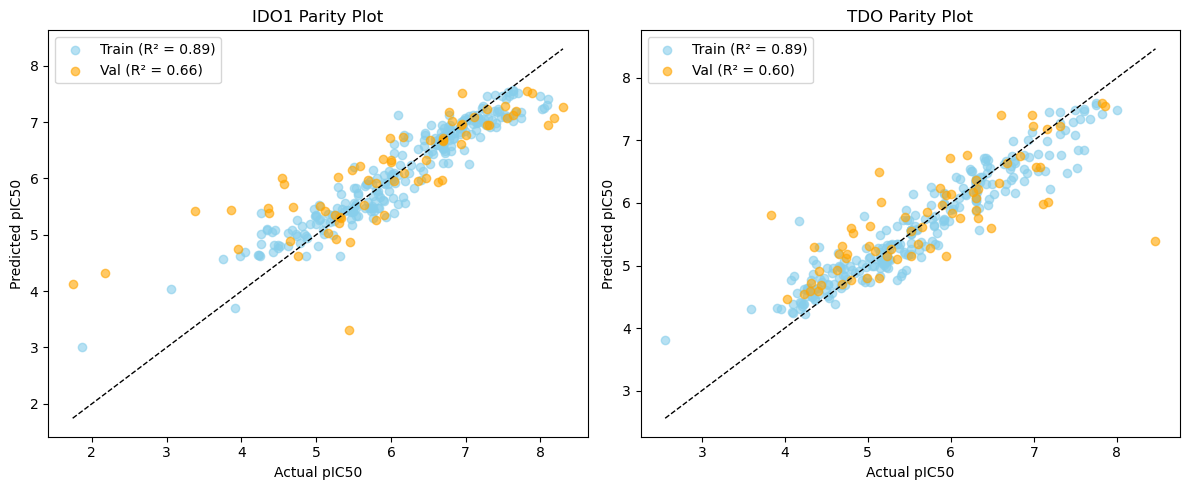

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

targets = ['IDO1', 'TDO']
train_preds = [y_train_pred[:, 0], y_train_pred[:, 1]]
val_preds = [y_val_pred[:, 0], y_val_pred[:, 1]]
train_true = [y_train.iloc[:, 0], y_train.iloc[:, 1]]
val_true = [y_val.iloc[:, 0], y_val.iloc[:, 1]]
r2_train = r2_per_target_train
r2_val = r2_per_target_val

for i in range(2):
    ax = axes[i]
    ax.scatter(train_true[i], train_preds[i], color='skyblue', alpha=0.6, label=f'Train (R² = {r2_train[i]:.2f})')
    ax.scatter(val_true[i], val_preds[i], color='orange', alpha=0.6, label=f'Val (R² = {r2_val[i]:.2f})')
    ax.plot([min(train_true[i].min(), val_true[i].min()), max(train_true[i].max(), val_true[i].max())],
            [min(train_true[i].min(), val_true[i].min()), max(train_true[i].max(), val_true[i].max())],
            'k--', lw=1)
    ax.set_title(f'{targets[i]} Parity Plot')
    ax.set_xlabel('Actual pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.legend()

plt.tight_layout()
plt.savefig("parity_plot.png", dpi=300)
plt.show()

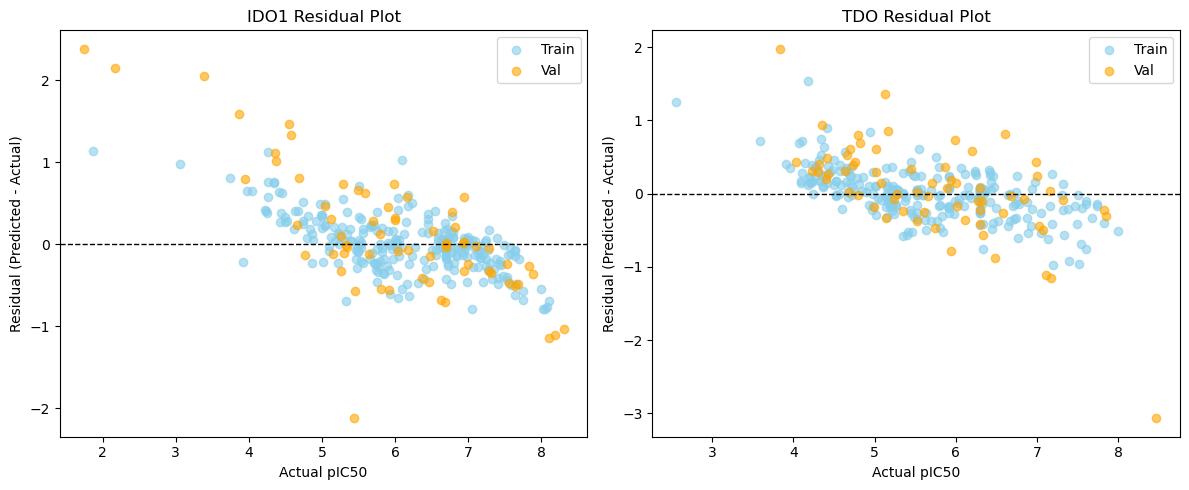

In [ ]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    ax = axes[i]
    target = targets[i]

    # Residuals
    residuals_train = train_preds[i] - train_true[i]
    residuals_val = val_preds[i] - val_true[i]

    ax.scatter(train_true[i], residuals_train, color='skyblue', alpha=0.6, label='Train')
    ax.scatter(val_true[i], residuals_val, color='orange', alpha=0.6, label='Val')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    ax.set_title(f'{target} Residual Plot')
    ax.set_xlabel('Actual pIC50')
    ax.set_ylabel('Residual (Predicted - Actual)')
    ax.legend()

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()

### 4. Y-randomization and 10-fold CV

In [ ]:
from sklearn.metrics import r2_score
import numpy as np
import copy

# Set seed for reproducibility
np.random.seed(42)

# Copy base model structure
rf_template = copy.deepcopy(model)  # model = MultiOutputRegressor(best_model)

# Lists to collect scores
r2_scramble_mean_scores = []
r2_scramble_ido1 = []
r2_scramble_tdo = []

n_repeats = 100

for _ in range(n_repeats):
    # Shuffle each target column independently
    y_scrambled = y_train.copy()
    for col in y_scrambled.columns:
        y_scrambled[col] = np.random.permutation(y_scrambled[col].values)

    # Fit scrambled model
    rf_scrambled = copy.deepcopy(rf_template)
    rf_scrambled.fit(X_train, y_scrambled)

    # Predict on validation set
    y_pred_scrambled = rf_scrambled.predict(X_val)

    # R² per target
    r2_per_target = r2_score(y_val, y_pred_scrambled, multioutput='raw_values')
    r2_scramble_ido1.append(r2_per_target[0])
    r2_scramble_tdo.append(r2_per_target[1])

    # Average R²
    r2_scramble_mean_scores.append(
        r2_score(y_val, y_pred_scrambled, multioutput='uniform_average')
    )

# Report mean R² scramble
print(f"\nR²_scramble (mean of {n_repeats} runs):")
print(f"Average : {np.mean(r2_scramble_mean_scores):.3f}")
print(f"IDO1    : {np.mean(r2_scramble_ido1):.3f}")
print(f"TDO     : {np.mean(r2_scramble_tdo):.3f}")


R²_scramble (mean of 100 runs):
Average : -0.123
IDO1    : -0.098
TDO     : -0.148


In [ ]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score

# Use the final model structure you already trained with best params
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validated predictions (on full training set)
y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=-1)

# Q² scores
q2_avg = r2_score(y_train, y_pred_cv, multioutput='uniform_average')
q2_per_target = r2_score(y_train, y_pred_cv, multioutput='raw_values')

# Print results
print(f"Q²_10-fold (Average): {q2_avg:.3f}")
print(f"Q²_10-fold (IDO1):    {q2_per_target[0]:.3f}")
print(f"Q²_10-fold (TDO):     {q2_per_target[1]:.3f}")

Q²_10-fold (Average): 0.636
Q²_10-fold (IDO1):    0.615
Q²_10-fold (TDO):     0.657


### 7. Applicability domain (Williams plot)

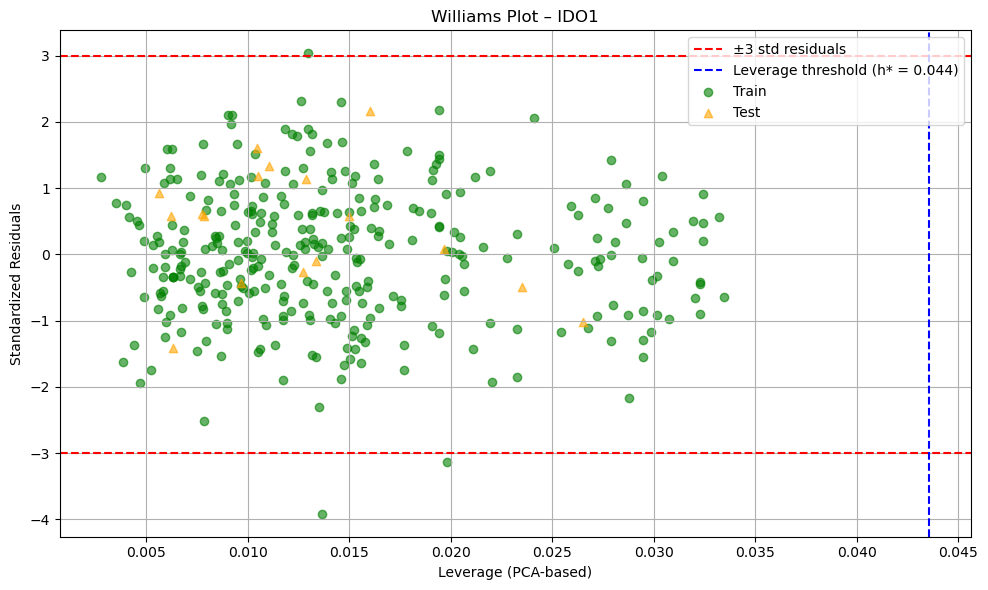

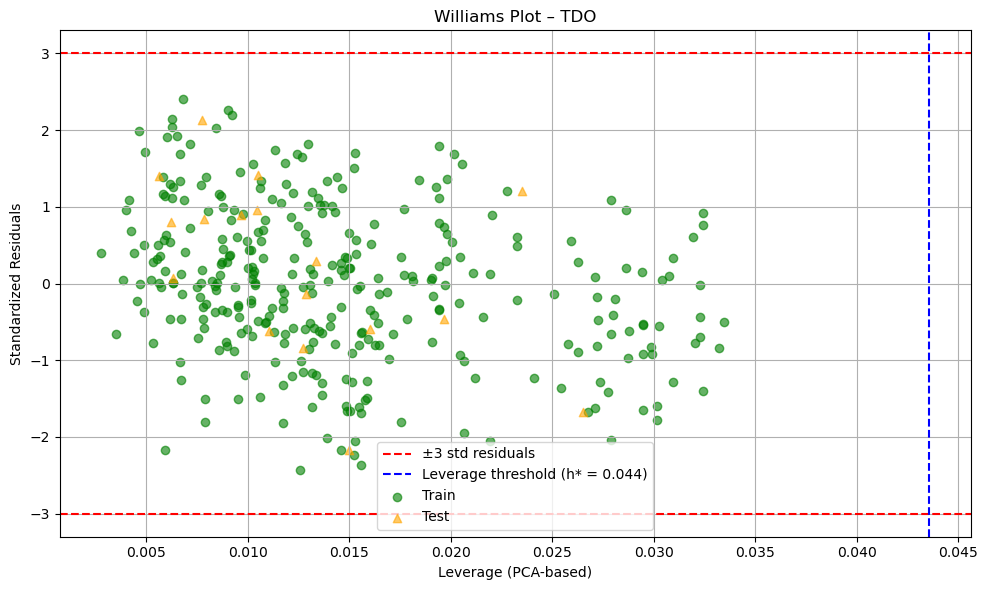

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Combine X and y
X_total = pd.concat([X_train_clean, X_test_clean], ignore_index=True)
y_total = pd.concat([y_train.reset_index(drop=True), y_test.reset_index(drop=True)], ignore_index=True)

# Predict
y_pred_total = pd.DataFrame(model.predict(X_total), columns=['IDO1_pred', 'TDO_pred'])

# PCA for leverage
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_total)
X_pca_const = np.hstack([np.ones((X_pca.shape[0], 1)), X_pca])
H = X_pca_const @ np.linalg.pinv(X_pca_const.T @ X_pca_const) @ X_pca_const.T
leverage = np.diag(H)

# Leverage threshold
p = X_pca.shape[1]
n = X_pca.shape[0]
h_star = 3 * (p + 1) / n

# Plot per target
for i, target in enumerate(['IDO1', 'TDO']):
    residuals = y_total.iloc[:, i] - y_pred_total.iloc[:, i]
    std_residuals = residuals / residuals.std()

    # Train/test split
    n_train = len(X_train_clean)
    std_resid_train = std_residuals[:n_train]
    std_resid_test = std_residuals[n_train:]
    leverage_train = leverage[:n_train]
    leverage_test = leverage[n_train:]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.axhline(y=3, color='red', linestyle='--', label='±3 std residuals')
    plt.axhline(y=-3, color='red', linestyle='--')
    plt.axvline(x=h_star, color='blue', linestyle='--', label=f'Leverage threshold (h* = {h_star:.3f})')

    plt.scatter(leverage_train, std_resid_train, c='green', alpha=0.6, label='Train', marker='o')
    plt.scatter(leverage_test, std_resid_test, c='orange', alpha=0.6, label='Test', marker='^')

    plt.xlabel("Leverage (PCA-based)")
    plt.ylabel("Standardized Residuals")
    plt.title(f"Williams Plot – {target}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"williams_{target.lower()}.png", dpi=300)
    plt.show()

In [ ]:
print("Leverage threshold (h*):", h_star)
print("Leverage min/max:", leverage.min(), leverage.max())
print("Std residuals range:", std_residuals.min(), std_residuals.max())

Leverage threshold (h*): 0.043583535108958835
Leverage min/max: 0.0027743842317527814 0.03345758434751656
Std residuals range: -2.430832309026698 2.4032928223263443


In [ ]:
import joblib

joblib.dump(model, "catboost_multi_target.pkl")

['catboost_multi_target.pkl']

### 9. Machine learning-based virtual screening

In [ ]:
model = joblib.load("catboost_multi_target.pkl")
model

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x7bea7b784fa0>)

In [ ]:
# 1. Load drugbank dataset
import pandas as pd
coconut_df = pd.read_csv("coconut_csv_lite-07-2025.csv")
coconut_df

/tmp/ipykernel_430/1825448285.py:3: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  coconut_df = pd.read_csv("coconut_csv_lite-07-2025.csv")


,ID,SMILES,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,murcko_framework,np_likeness,chemical_class,chemical_sub_class,chemical_super_class,direct_parent_classification,np_classifier_pathway,np_classifier_superclass,np_classifier_class,np_classifier_is_glycoside
0,CNP0455766.1,COCC(=O)N[C@@H]1CO[C@@H]2[C@@H]1OC[C@@H]2N1N=N...,InChI=1S/C18H20N8O5/c1-28-8-15(27)21-13-6-29-1...,LVNSOJWZQFQBOP-WTTBNOFXSA-N,NaN,"~{N}-[(3~{R},3~{a}~{R},6~{S},6~{a}~{S})-6-[5-[...",2,51,31,428.41,...,n1nc(Oc2ccc(cc2)-n3ncnc3)n(n1)C4COC5CCOC54,-2.12,Organooxygen compounds,Ethers,Organic oxygen compounds,Diarylethers,Alkaloids,NaN,NaN,False
1,CNP0595928.1,COC1=CC=C(C[C@H]2C3=CC(OC)=C(OC)C(O)=C3CC[N+]2...,InChI=1S/C40H46N2O8/c1-41-16-14-28-29(21-36-40...,QQJYBIOINVHLKO-ACHIHNKUSA-O,Thalirabine,"(1~{S})-6,7-dimethoxy-1-[[4-methoxy-3-[4-[[(5~...",4,97,50,683.82,...,O(c1ccc(cc1)CC2NCCc3cc4OCOc4cc32)c5cccc(c5)CC6...,1.24,Isoquinolines and derivatives,Benzylisoquinolines,Organoheterocyclic compounds,Benzylisoquinolines,Alkaloids,Tyrosine alkaloids,Isoquinoline alkaloids,False
2,CNP0212937.2,O=C1C(O[C@H]2O[C@@H](CO[C@@H]3O[C@H](CO)[C@@H]...,InChI=1S/C27H30O17/c28-6-14-17(33)20(36)22(38)...,FDRQPMVGJOQVTL-QUGXUONWSA-N,NaN,"2-(3,4-dihydroxyphenyl)-5,7-dihydroxy-3-[(2~{R...",2,74,44,626.52,...,O1c2ccccc2CC(OC3OC(COC4OCCCC4)CCC3)=C1c5ccccc5,1.86,Flavonoids,Flavonoid glycosides,Phenylpropanoids and polyketides,Flavonoid-3-O-glycosides,Shikimates and Phenylpropanoids,Flavonoids,Flavonols,True
3,CNP0065116.0,COC1=CC=C2C(=C1)C(C=C1OC3=CC(OCC(=O)OC(C)(C)C)...,"InChI=1S/C25H25NO6/c1-25(2,3)32-23(27)14-30-17...",QZOLADXWXZWHPX-UHFFFAOYSA-N,NaN,~{tert}-butyl 2-[2-[(5-methoxy-1-methyl-indol-...,2,57,32,435.48,...,O1c2ccccc2CC1=Cc3c[nH]c4ccccc34,-0.75,Benzene and substituted derivatives,Phenoxyacetic acid derivatives,Benzenoids,Phenoxyacetic acid derivatives,Shikimates and Phenylpropanoids,NaN,NaN,False
4,CNP0163187.1,CC[C@H](C)[C@@H]1OC(C)(C)O[C@]1(C)/C=C/C1=CC2=...,"InChI=1S/C22H32O6/c1-7-13(2)19-21(5,28-20(3,4)...",IWEMHAGFVAXHLO-VEKXZWMCSA-N,NaN,"(7~{R},8~{R},8~{a}~{R})-7,8-dihydroxy-7-methyl...",2,60,28,392.49,...,O1C(C=CC2OCOC2)=CC3=CCCCC3C1,2.37,Azaphilones,Azaphilones,Organoheterocyclic compounds,Azaphilones,Polyketides,Chromanes,Azaphilones,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695114,CNP0282608.1,OC[C@@H](CC1=CC=C2OCOC2=C1)[C@@H](CO)CC1=CC=C2...,InChI=1S/C20H22O6/c21-9-15(5-13-1-3-17-19(7-13...,JKCVMTYNARDGET-HZPDHXFCSA-N,"Dihydrocubebin, rel-","(2~{S},3~{S})-2,3-bis(1,3-benzodioxol-5-ylmeth...",5,48,26,358.39,...,O1c2ccc(cc2OC1)CCCCc3ccc4OCOc4c3,0.55,Dibenzylbutane lignans,Dibenzylbutane lignans,"Lignans, neolignans and related compounds",Dibenzylbutane lignans,Shikimates and Phenylpropanoids,Lignans,Arylnaphthalene and aryltetralin lignans,False
695115,CNP0288119.1,COC1=CC(OC)=C2C(=O)C[C@@H](C3=CC=CC=C3)OC2=C1,InChI=1S/C17H16O4/c1-19-12-8-15(20-2)17-13(18)...,IAFBOKYTDSDNHV-AWEZNQCLSA-N,"(2S)-5,7-dimethoxy-2-phenyl-3,4-dihydro-2H-1-b...","(2~{S})-5,7-dimethoxy-2-phenyl-chroman-4-one",5,37,21,284.31,...,O1c2ccccc2CCC1c3ccccc3,1.07,Flavonoids,O-methylated flavonoids,Phenylpropanoids and polyketides,5-O-methylated flavonoids,Shikimates and Phenylpropanoids,Flavonoids,Flavanones,False
695116,CNP0139366.0,COC1=CC(C2=C(O)C(=O)C3=CC=C(O)C=C3O2)=CC(OC)=C1O,InChI=1S/C17H14O7/c1-22-12-5-8(6-13(23-2)15(12...,HORABUFWIBXDQQ-UHFFFAOYSA-N,Laurentinol,"3,7-dihydroxy-2-(4-hydroxy-3,5-dimethoxy-pheny...",4,38,24,330.29,...,O1c2ccccc2CC=C1c3ccccc3,1.07,Flavonoids,Flavones,Phenylpropanoids and polyketides,Flavonols,Shikimates and Phenylpropanoids,Flavonoids,Flavonols,False
695117,CNP0338856.1,COC1=CC(O)=CC(C2=CC3=CC(O)=C4O[C@](C)(CO)C=CC4...,InChI=1S/C20H18O6/c1-20(10-21)4-3-15-18-12(7-1...,HVNMYEKTMWVINM-FQEVSTJZSA-N,NaN,(7~{S})-2-(3-hydroxy-5-methoxy-phenyl)-7-(hydr...,1,44,26,354.36,...,o1c(cc2ccc3OCC=Cc3c12)-c4ccccc4,2.35,2-arylbenzofuran flavono

In [ ]:
coconut_df.columns

Index(['ID', 'SMILES', 'standard_inchi', 'standard_inchi_key', 'name',
       'iupac_name', 'annotation_level', 'total_atom_count',
       'heavy_atom_count', 'molecular_weight', 'exact_molecular_weight',
       'molecular_formula', 'alogp', 'topological_polar_surface_area',
       'rotatable_bond_count', 'hydrogen_bond_acceptors',
       'hydrogen_bond_donors', 'hydrogen_bond_acceptors_lipinski',
       'hydrogen_bond_donors_lipinski', 'lipinski_rule_of_five_violations',
       'aromatic_rings_count', 'qed_drug_likeliness', 'formal_charge',
       'fractioncsp3', 'number_of_minimal_rings', 'van_der_walls_volume',
       'contains_sugar', 'contains_ring_sugars', 'contains_linear_sugars',
       'murcko_framework', 'np_likeness', 'chemical_class',
       'chemical_sub_class', 'chemical_super_class',
       'direct_parent_classification', 'np_classifier_pathway',
       'np_classifier_superclass', 'np_classifier_class',
       'np_classifier_is_glycoside'],
      dtype='object')

In [ ]:
# Filter compounds with 0 violations including rotatable bond count
coconut_df_ro5 = coconut_df[
    (coconut_df['molecular_weight'] <= 500) &
    (coconut_df['alogp'] <= 5) &
    (coconut_df['hydrogen_bond_donors_lipinski'] <= 5) &
    (coconut_df['hydrogen_bond_acceptors_lipinski'] <= 10) &
    (coconut_df['rotatable_bond_count'] <= 10)
].copy()

In [ ]:
coconut_df_ro5

,ID,SMILES,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,murcko_framework,np_likeness,chemical_class,chemical_sub_class,chemical_super_class,direct_parent_classification,np_classifier_pathway,np_classifier_superclass,np_classifier_class,np_classifier_is_glycoside
3,CNP0065116.0,COC1=CC=C2C(=C1)C(C=C1OC3=CC(OCC(=O)OC(C)(C)C)...,"InChI=1S/C25H25NO6/c1-25(2,3)32-23(27)14-30-17...",QZOLADXWXZWHPX-UHFFFAOYSA-N,NaN,~{tert}-butyl 2-[2-[(5-methoxy-1-methyl-indol-...,2,57,32,435.48,...,O1c2ccccc2CC1=Cc3c[nH]c4ccccc34,-0.75,Benzene and substituted derivatives,Phenoxyacetic acid derivatives,Benzenoids,Phenoxyacetic acid derivatives,Shikimates and Phenylpropanoids,NaN,NaN,False
4,CNP0163187.1,CC[C@H](C)[C@@H]1OC(C)(C)O[C@]1(C)/C=C/C1=CC2=...,"InChI=1S/C22H32O6/c1-7-13(2)19-21(5,28-20(3,4)...",IWEMHAGFVAXHLO-VEKXZWMCSA-N,NaN,"(7~{R},8~{R},8~{a}~{R})-7,8-dihydroxy-7-methyl...",2,60,28,392.49,...,O1C(C=CC2OCOC2)=CC3=CCCCC3C1,2.37,Azaphilones,Azaphilones,Organoheterocyclic compounds,Azaphilones,Polyketides,Chromanes,Azaphilones,False
6,CNP0136743.0,CSCCC=O,"InChI=1S/C4H8OS/c1-6-4-2-3-5/h3H,2,4H2,1H3",CLUWOWRTHNNBBU-UHFFFAOYSA-N,3-(Methylthio)propionaldehyde,3-methylsulfanylpropanal,5,14,6,104.17,...,NaN,0.61,Organooxygen compounds,Carbonyl compounds,Organic oxygen compounds,Alpha-hydrogen aldehydes,Fatty acids,Fatty acyls,Fatty aldehydes,False
7,CNP0605694.2,COC1=CC=C(C=C2C(=O)N[C@@]3(C[C@]4(O)[C@H](C=C[...,InChI=1S/C21H24N2O9/c1-23-11(8-10-4-6-13(30-2)...,HCKQCACCKTUAQG-NSBANYLGSA-N,Penispirozine G,"(2~{R},3~{a}~{R},4~{S},5~{R},7~{a}~{S})-3~{a},...",3,56,32,448.43,...,O1C2C=CCCC2CC13NCC(=Cc4ccccc4)NC3,1.20,Phenols,Methoxyphenols,Benzenoids,Methoxyphenols,Amino acids and Peptides,NaN,NaN,False
8,CNP0491772.0,[Cd+2],InChI=1S/Cd/q+2,WLZRMCYVCSSEQC-UHFFFAOYSA-N,Cadmium ion,cadmium(2+),5,1,1,112.41,...,NaN,0.00,NaN,Organic cations,Organic cations,Organic cations,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695113,CNP0301642.1,COC1=CC=C2C[C@H](O)[C@@H](C3=CC=C4OCOC4=C3)OC2=C1,InChI=1S/C17H16O5/c1-19-12-4-2-10-6-13(18)17(2...,AZZPFHOMXVQGOU-SUMWQHHRSA-N,NaN,"(2~{R},3~{S})-2-(1,3-benzodioxol-5-yl)-7-metho...",1,38,22,300.31,...,O1c2ccc(cc2OC1)C3Oc4ccccc4CC3,1.07,Flavonoids,O-methylated flavonoids,Phenylpropanoids and polyketides,7-O-methylated flavonoids,Shikimates and Phenylpropanoids,Flavonoids,Flavan-3-ols,False
695114,CNP0282608.1,OC[C@@H](CC1=CC=C2OCOC2=C1)[C@@H](CO)CC1=CC=C2...,InChI=1S/C20H22O6/c21-9-15(5-13-1-3-17-19(7-13...,JKCVMTYNARDGET-HZPDHXFCSA-N,"Dihydrocubebin, rel-","(2~{S},3~{S})-2,3-bis(1,3-benzodioxol-5-ylmeth...",5,48,26,358.39,...,O1c2ccc(cc2OC1)CCCCc3ccc4OCOc4c3,0.55,Dibenzylbutane lignans,Dibenzylbutane lignans,"Lignans, neolignans and related compounds",Dibenzylbutane lignans,Shikimates and Phenylpropanoids,Lignans,Arylnaphthalene and aryltetralin lignans,False
695115,CNP0288119.1,COC1=CC(OC)=C2C(=O)C[C@@H](C3=CC=CC=C3)OC2=C1,InChI=1S/C17H16O4/c1-19-12-8-15(20-2)17-13(18)...,IAFBOKYTDSDNHV-AWEZNQCLSA-N,"(2S)-5,7-dimethoxy-2-phenyl-3,4-dihydro-2H-1-b...","(2~{S})-5,7-dimethoxy-2-phenyl-chroman-4-one",5,37,21,284.31,...,O1c2ccccc2CCC1c3ccccc3,1.07,Flavonoids,O-methylated flavonoids,Phenylpropanoids and polyketides,5-O-methylated flavonoids,Shikimates and Phenylpropanoids,Flavonoids,Flavanones,False
695116,CNP0139366.0,COC1=CC(C2=C(O)C(=O)C3=CC=C(O)C=C3O2)=CC(OC)=C1O,InChI=1S/C17H14O7/c1-22-12-5-8(6-13(23-2)15(12...,HORABUFWIBXDQQ-UHFFFAOYSA-N,Laurentinol,"3,7-dihydroxy-2-(4-hydroxy-3,5-dimethoxy-pheny...",4,38,24,330.29,...,O1c2ccccc2CC=C1c3ccccc3,1.07,Flavonoids,Flavones,Phenylpropanoids and polyketides,Flavonols,Shikimates and Phenylpropanoids,Flavonoids,Flavonols,False


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
from tqdm import tqdm

# ECFP4 generator
def get_ecfp4_array(smiles, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=nBits)
        return list(fp)
    else:
        return None

# Enable tqdm progress
tqdm.pandas()

# Generate ECFP4 fingerprints with progress bar
coconut_df_ro5['ecfp4'] = coconut_df_ro5['SMILES'].progress_apply(get_ecfp4_array)

# Drop failed SMILES
coconut_df_ro5 = coconut_df_ro5[coconut_df_ro5['ecfp4'].notnull()].reset_index(drop=True)

# Expand fingerprints into separate columns
fp_df = pd.DataFrame(coconut_df_ro5['ecfp4'].to_list(), columns=[f'fp_{i}' for i in range(2048)])

# Join and save
coconut_fp = pd.concat([coconut_df_ro5.drop(columns=['ecfp4']), fp_df], axis=1)
coconut_fp.to_csv("coconut_ro5_ecfp4.csv", index=False)

100%|█████████████████████████████████████████████████████████████████████████| 353466/353466 [03:56<00:00, 1493.79it/s]


In [ ]:
#coconut_fp
coconut_fp = pd.read_csv("coconut_ro5_ecfp4.csv")
coconut_fp

,ID,SMILES,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,CNP0065116.0,COC1=CC=C2C(=C1)C(C=C1OC3=CC(OCC(=O)OC(C)(C)C)...,"InChI=1S/C25H25NO6/c1-25(2,3)32-23(27)14-30-17...",QZOLADXWXZWHPX-UHFFFAOYSA-N,NaN,~{tert}-butyl 2-[2-[(5-methoxy-1-methyl-indol-...,2,57,32,435.48,...,0,0,0,0,0,0,0,0,0,0
1,CNP0163187.1,CC[C@H](C)[C@@H]1OC(C)(C)O[C@]1(C)/C=C/C1=CC2=...,"InChI=1S/C22H32O6/c1-7-13(2)19-21(5,28-20(3,4)...",IWEMHAGFVAXHLO-VEKXZWMCSA-N,NaN,"(7~{R},8~{R},8~{a}~{R})-7,8-dihydroxy-7-methyl...",2,60,28,392.49,...,0,0,0,0,1,0,0,0,0,0
2,CNP0136743.0,CSCCC=O,"InChI=1S/C4H8OS/c1-6-4-2-3-5/h3H,2,4H2,1H3",CLUWOWRTHNNBBU-UHFFFAOYSA-N,3-(Methylthio)propionaldehyde,3-methylsulfanylpropanal,5,14,6,104.17,...,0,0,0,0,0,0,0,0,0,0
3,CNP0605694.2,COC1=CC=C(C=C2C(=O)N[C@@]3(C[C@]4(O)[C@H](C=C[...,InChI=1S/C21H24N2O9/c1-23-11(8-10-4-6-13(30-2)...,HCKQCACCKTUAQG-NSBANYLGSA-N,Penispirozine G,"(2~{R},3~{a}~{R},4~{S},5~{R},7~{a}~{S})-3~{a},...",3,56,32,448.43,...,0,0,0,0,0,0,0,0,0,0
4,CNP0491772.0,[Cd+2],InChI=1S/Cd/q+2,WLZRMCYVCSSEQC-UHFFFAOYSA-N,Cadmium ion,cadmium(2+),5,1,1,112.41,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353461,CNP0301642.1,COC1=CC=C2C[C@H](O)[C@@H](C3=CC=C4OCOC4=C3)OC2=C1,InChI=1S/C17H16O5/c1-19-12-4-2-10-6-13(18)17(2...,AZZPFHOMXVQGOU-SUMWQHHRSA-N,NaN,"(2~{R},3~{S})-2-(1,3-benzodioxol-5-yl)-7-metho...",1,38,22,300.31,...,0,0,0,0,0,0,0,0,0,0
353462,CNP0282608.1,OC[C@@H](CC1=CC=C2OCOC2=C1)[C@@H](CO)CC1=CC=C2...,InChI=1S/C20H22O6/c21-9-15(5-13-1-3-17-19(7-13...,JKCVMTYNARDGET-HZPDHXFCSA-N,"Dihydrocubebin, rel-","(2~{S},3~{S})-2,3-bis(1,3-benzodioxol-5-ylmeth...",5,48,26,358.39,...,0,0,0,0,0,0,0,0,0,0
353463,CNP0288119.1,COC1=CC(OC)=C2C(=O)C[C@@H](C3=CC=CC=C3)OC2=C1,InChI=1S/C17H16O4/c1-19-12-8-15(20-2)17-13(18)...,IAFBOKYTDSDNHV-AWEZNQCLSA-N,"(2S)-5,7-dimethoxy-2-phenyl-3,4-dihydro-2H-1-b...","(2~{S})-5,7-dimethoxy-2-phenyl-chroman-4-one",5,37,21,284.31,...,0,0,0,0,0,0,0,0,0,0
353464,CNP0139366.0,COC1=CC(C2=C(O)C(=O)C3=CC=C(O)C=C3O2)=CC(OC)=C1O,InChI=1S/C17H14O7/c1-22-12-5-8(6-13(23-2)15(12...,HORABUFWIBXDQQ-UHFFFAOYSA-N,Laurentinol,"3,7-dihydroxy-2-(4-hydroxy-3,5-dimethoxy-pheny...",4,38,24,330.29,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Select only fingerprint columns
fp_cols = [col for col in coconut_fp.columns if col.startswith('fp_')]

# Prepare input for prediction
X_coconut = coconut_fp[fp_cols]

# Predict pIC50 for both targets
predictions = model.predict(X_coconut)

# Add predicted values to DataFrame
coconut_fp['Pred_IDO1'] = predictions[:, 0]
coconut_fp['Pred_TDO'] = predictions[:, 1]

# Save without fingerprints
coconut_fp.drop(columns=fp_cols).to_csv("coconut_predictions.csv", index=False)

### 10. Applicability domain for predicted compounds (Mahalanobis distance)

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import distance
from scipy.stats import chi2
from sklearn.decomposition import PCA

# --- 1. Align fingerprint features ---
fp_cols = X_train_clean.columns.tolist()

# Add missing fingerprint columns to coconut_fp
for col in fp_cols:
    if col not in coconut_fp.columns:
        coconut_fp[col] = 0

# Reorder columns
X_coconut = coconut_fp[fp_cols].copy()

# --- 2. PCA (20 components) ---
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_clean[fp_cols])
X_coconut_pca = pca.transform(X_coconut)

# --- 3. Mahalanobis distance ---
mean_vec = np.mean(X_train_pca, axis=0)
cov_matrix = np.cov(X_train_pca, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)

mahal_dist = np.array([
    distance.mahalanobis(x, mean_vec, inv_cov_matrix)
    for x in X_coconut_pca
])

threshold = np.sqrt(chi2.ppf(0.95, df=20))

# --- 4. Predict pIC50 ---
y_pred_coconut = model.predict(X_coconut)

# --- 5. Annotate & save ---
coconut_fp['Predicted_pIC50_IDO1'] = y_pred_coconut[:, 0]
coconut_fp['Predicted_pIC50_TDO'] = y_pred_coconut[:, 1]
coconut_fp['Mahalanobis'] = mahal_dist
coconut_fp['Inside_AD'] = mahal_dist <= threshold

# Save selected info
cols_to_save = ['SMILES', 'Predicted_pIC50_IDO1', 'Predicted_pIC50_TDO', 'Mahalanobis', 'Inside_AD']
coconut_fp[cols_to_save].to_csv("coconut_with_predictions_ad.csv", index=False)

In [ ]:
# --- Filter by Applicability Domain ---
filtered_df = coconut_fp[coconut_fp['Inside_AD']]

# --- Filter for strong predicted activity (pIC50 > 6) for both targets ---
filtered_df = filtered_df[
    (filtered_df['Predicted_pIC50_IDO1'] > 6) &
    (filtered_df['Predicted_pIC50_TDO'] > 6)
]

# --- Save filtered compounds ---
filtered_df.to_csv("coconut_filtered_active_inside_ad.csv", index=False)